# NeuralProphet Forecasting

## Imports

In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from neuralprophet import NeuralProphet
from sklearn.metrics import mean_squared_error, mean_absolute_error


## Load Dataset

In [5]:
df = pd.read_csv('oil_price.csv')

df['ds'] = pd.to_datetime(df['observation_date'])
df['y'] = df['DCOILWTICO']
df = df[['ds','y']].sort_values('ds').dropna()



## Data Cleaning & Missing Values

In [6]:
# cleaning
df = df.drop_duplicates().reset_index(drop=True)
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df = df.fillna(method='ffill').fillna(method='bfill')

# resample
df = df.set_index('ds').asfreq('D')
df['y'] = df['y'].interpolate()
df = df.reset_index()

## Train / Validation / Test Split (70/10/20)

In [7]:
train_size = int(len(df)*0.7)
val_size   = int(len(df)*0.1)

train_df = df[:train_size]
val_df   = df[train_size:train_size+val_size]
test_df  = df[train_size+val_size:]


## Model (NeuralProphet)

In [8]:
model = NeuralProphet(
    n_forecasts=1,
    n_lags=14,
    yearly_seasonality=True,
    weekly_seasonality=True,
    epochs=200
)


## Training with Early Stopping

In [9]:
model.fit(
    train_df,
    freq='D',
    validation_df=val_df,
    early_stopping=True,
    progress='bar'
)


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.99% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 128


Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (81) is too small than the required number                     for the learning rate finder (250). The results might not be optimal.


Finding best initial lr:   0%|          | 0/250 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

,MAE_val,RMSE_val,Loss_val,RegLoss_val,epoch,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss
0,104.466507,127.694611,1.022236,0.0,0,0.913414,0.0,115.318428,142.329102,0.909317,0.0
1,55.744343,73.967987,0.493244,0.0,1,0.477027,0.0,67.084274,87.733330,0.476494,0.0
2,44.869629,56.248203,0.368399,0.0,2,0.312260,0.0,49.182323,62.021088,0.312449,0.0
3,37.522583,46.597649,0.290503,0.0,3,0.246484,0.0,41.394611,50.991180,0.247889,0.0
4,31.027626,38.447426,0.223002,0.0,4,0.192096,0.0,34.273693,42.197731,0.191946,0.0
...,...,...,...,...,...,...,...,...,...,...,...
195,0.893631,1.152838,0.000294,0.0,195,0.000266,0.0,0.719110,1.165383,0.000264,0.0
196,0.892132,1.149293,0.000291,0.0,196,0.000265,0.0,0.720078,1.167049,0.000266,0.0
197,0.892427,1.150661,0.000293,0.0,197,0.000265,0.0,0.712943,1.158381,0.000263,0.0
198,0.891405,1.148331,0.000291,0.0,198,0.000264,0.0,0.716857,1.166097,0.000264,0.0


## Forecast & Evaluation

In [10]:
forecast = model.predict(df)

forecast_test = forecast.iloc[-len(test_df):].copy()
forecast_test = forecast_test[['yhat1']].dropna()

y_pred = forecast_test['yhat1'].values
y_true = test_df['y'].iloc[:len(y_pred)].values

mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.993% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.993% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


## Metrics

In [15]:
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom[denom == 0] = 1e-8
    return 100/len(y_true) * np.sum(2*np.abs(y_pred - y_true)/denom)

def mase(y_true, y_pred, y_train):
    naive = np.mean(np.abs(np.diff(y_train)))
    if naive == 0:
        naive = 1e-8
    return np.mean(np.abs(y_true - y_pred)) / naive

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
smape_val = smape(y_true, y_pred)
mase_val = mase(y_true, y_pred, train_df['y'].values)

print('RMSE:', rmse)
print('MAE :', mae)
print('sMAPE:', smape_val)
print('MASE :', mase_val)


RMSE: 2.2815429278814148
MAE : 1.3563858186131958
sMAPE: 2.5886127637314558
MASE : 2.8987573545186476


## Plot

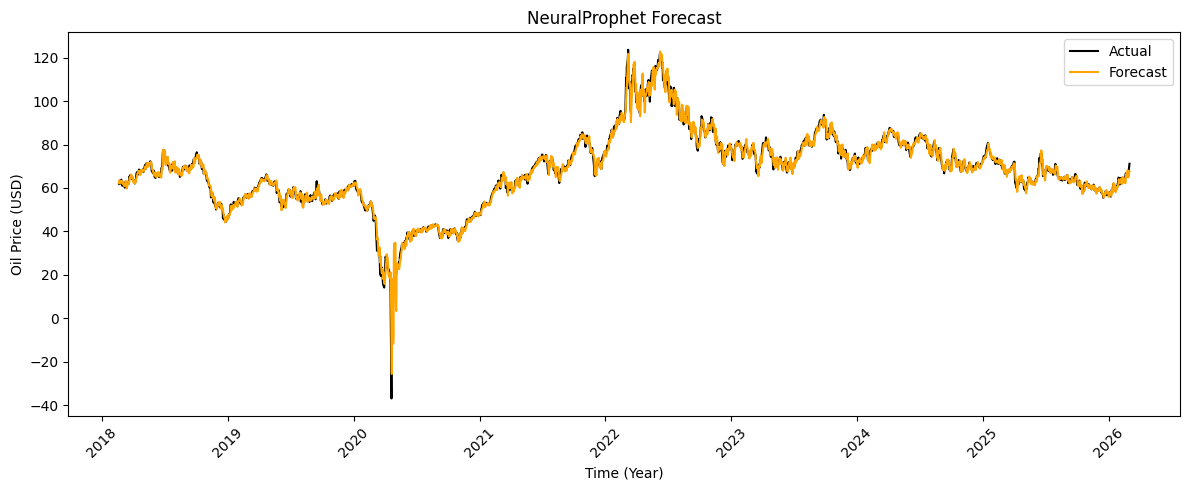

In [26]:
plt.figure(figsize=(12,5))

# ambil waktu dari test_df
time_index = test_df['ds'].iloc[:len(y_true)]

plt.plot(time_index, y_true, label='Actual', color="black")
plt.plot(time_index, y_pred, label='Forecast', color='orange')

plt.legend()
plt.title('NeuralProphet Forecast')
plt.xlabel('Time (Year)')
plt.ylabel('Oil Price (USD)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()